<a href="https://colab.research.google.com/github/morozovsolncev/gravitation/blob/main/massa_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


ЭТАП В1: ГРАВИТАЦИЯ (ОНТОЛОГИЧЕСКАЯ)

Запуск частицы из правого верхнего угла с нулевой скоростью...
   шагов: 201
   финальная позиция: (9.00, 9.00)
   финальная скорость: (0.000, 0.000)

Запуск частицы из левого нижнего угла с начальной скоростью...
   шагов: 201
   финальная позиция: (-1.02, 1.49)
   финальная скорость: (-0.698, -0.197)


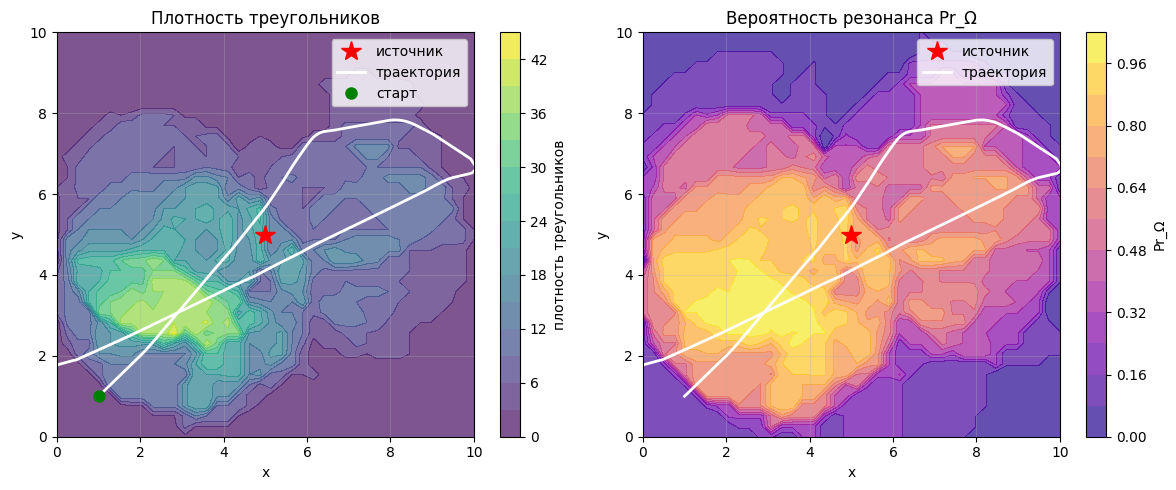


ЭТАП В1 ЗАВЕРШЁН


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ЭТАП В1: ГРАВИТАЦИЯ (ОНТОЛОГИЧЕСКАЯ)
Движение по градиенту логарифма вероятности резонанса
"""

import numpy as np
import matplotlib.pyplot as plt

class OntologicalGravityModel:
    def __init__(self, n=150, p_base=0.5, source_mass=20, source_radius=3, eta=1.0, seed=None):
        self.n = n
        self.p_base = p_base
        self.source_mass = source_mass
        self.source_radius = source_radius
        self.eta = eta  # константа перевода (аналог c^2)

        if seed is not None:
            np.random.seed(seed)

        # Пространство
        self.adj = np.zeros((n, n), dtype=bool)
        self.weights = np.zeros((n, n), dtype=float)
        self.positions = np.random.rand(n, 2) * 10

        # Источник в центре (вершина 0)
        self.source_pos = np.array([5.0, 5.0])
        self.positions[0] = self.source_pos

        # Инициализация графа
        self.init_graph()

        # Пробная частица
        self.particle_pos = None
        self.particle_vel = None
        self.particle_history = {'x': [], 'y': [], 'vx': [], 'vy': [], 'step': []}

    def init_graph(self):
        for i in range(self.n):
            for j in range(i+1, self.n):
                dist = np.linalg.norm(self.positions[i] - self.positions[j])
                prob = self.p_base * np.exp(-dist / 5)

                if i == 0 or j == 0:
                    prob *= self.source_mass

                if np.random.random() < prob:
                    self.adj[i][j] = self.adj[j][i] = True
                    self.weights[i][j] = self.weights[j][i] = 1.0

    def count_triangles_near(self, pos, radius=3):
        """Число треугольников в окрестности точки (мера плотности связности)"""
        nearby = []
        for i in range(1, self.n):
            dist = np.linalg.norm(self.positions[i] - pos)
            if dist < radius:
                nearby.append(i)

        triangles = 0
        for i in nearby:
            for j in nearby:
                if i < j and self.adj[i][j]:
                    for k in nearby:
                        if j < k and self.adj[i][k] and self.adj[j][k]:
                            triangles += 1
        return triangles

    def probability_of_resonance(self, pos, radius=3):
        """
        Вероятность резонанса Pr_Ω в точке.
        Связана с плотностью треугольников, но не линейно.
        """
        rho = self.count_triangles_near(pos, radius)
        # Pr_Ω = exp(-1/ρ) или что-то подобное
        # Чем выше плотность, тем выше вероятность
        if rho > 0:
            return 1.0 - np.exp(-rho / 10)  # насыщается к 1
        else:
            return 0.0

    def log_probability_gradient(self, pos, radius=3, delta=0.1):
        """
        Градиент логарифма вероятности резонанса ∇[ln Pr_Ω]
        Вычисляется численно.
        """
        x, y = pos
        Pr0 = self.probability_of_resonance([x, y], radius)

        if Pr0 <= 0:
            return np.array([0.0, 0.0])

        # Производные по x и y
        Pr_x_plus = self.probability_of_resonance([x + delta, y], radius)
        Pr_x_minus = self.probability_of_resonance([x - delta, y], radius)
        Pr_y_plus = self.probability_of_resonance([x, y + delta], radius)
        Pr_y_minus = self.probability_of_resonance([x, y - delta], radius)

        # ln Pr = log(Pr)
        dlnP_dx = (np.log(Pr_x_plus) - np.log(Pr_x_minus)) / (2 * delta) if Pr_x_plus > 0 and Pr_x_minus > 0 else 0
        dlnP_dy = (np.log(Pr_y_plus) - np.log(Pr_y_minus)) / (2 * delta) if Pr_y_plus > 0 and Pr_y_minus > 0 else 0

        return np.array([dlnP_dx, dlnP_dy])

    def particle_step(self):
        """Один шаг движения: a = (η/2) · ∇[ln Pr_Ω]"""
        if self.particle_pos is None or self.particle_vel is None:
            return

        # Вычисляем ускорение
        grad = self.log_probability_gradient(self.particle_pos)
        acceleration = (self.eta / 2) * grad

        # Обновляем скорость и позицию (простая эйлерова интеграция)
        self.particle_vel += acceleration * 0.1
        self.particle_pos += self.particle_vel * 0.1

        # Сохраняем историю
        self.particle_history['x'].append(float(self.particle_pos[0]))
        self.particle_history['y'].append(float(self.particle_pos[1]))
        self.particle_history['vx'].append(float(self.particle_vel[0]))
        self.particle_history['vy'].append(float(self.particle_vel[1]))
        self.particle_history['step'].append(len(self.particle_history['x']))

    def run_particle(self, start_pos, start_vel=None, steps=100):
        """Запуск частицы с начальной позицией и скоростью"""
        self.particle_pos = np.array([float(start_pos[0]), float(start_pos[1])])
        if start_vel is None:
            self.particle_vel = np.array([0.0, 0.0])
        else:
            self.particle_vel = np.array([float(start_vel[0]), float(start_vel[1])])

        self.particle_history = {
            'x': [self.particle_pos[0]],
            'y': [self.particle_pos[1]],
            'vx': [self.particle_vel[0]],
            'vy': [self.particle_vel[1]],
            'step': [0]
        }

        for _ in range(steps):
            self.particle_step()

        return self.particle_history

    def plot_results(self):
        """Визуализация плотности и траектории"""
        # Карта плотности треугольников
        x = np.linspace(0, 10, 40)
        y = np.linspace(0, 10, 40)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X)

        for i in range(len(x)):
            for j in range(len(y)):
                Z[j, i] = self.count_triangles_near([X[j, i], Y[j, i]])

        plt.figure(figsize=(12, 5))

        # Левая часть: плотность треугольников
        plt.subplot(1, 2, 1)
        plt.contourf(X, Y, Z, levels=15, cmap='viridis', alpha=0.7)
        plt.colorbar(label='плотность треугольников')
        plt.plot(self.source_pos[0], self.source_pos[1], 'r*', markersize=15, label='источник')
        if self.particle_history['x']:
            plt.plot(self.particle_history['x'], self.particle_history['y'],
                    'w-', linewidth=2, label='траектория')
            plt.plot(self.particle_history['x'][0], self.particle_history['y'][0],
                    'go', markersize=8, label='старт')
        plt.xlim(0, 10)
        plt.ylim(0, 10)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Плотность треугольников')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Правая часть: вероятность резонанса
        plt.subplot(1, 2, 2)
        Z_pr = np.zeros_like(X)
        for i in range(len(x)):
            for j in range(len(y)):
                Z_pr[j, i] = self.probability_of_resonance([X[j, i], Y[j, i]])

        plt.contourf(X, Y, Z_pr, levels=15, cmap='plasma', alpha=0.7)
        plt.colorbar(label='Pr_Ω')
        plt.plot(self.source_pos[0], self.source_pos[1], 'r*', markersize=15, label='источник')
        if self.particle_history['x']:
            plt.plot(self.particle_history['x'], self.particle_history['y'],
                    'w-', linewidth=2, label='траектория')
        plt.xlim(0, 10)
        plt.ylim(0, 10)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Вероятность резонанса Pr_Ω')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


# ============================================================
# ЭКСПЕРИМЕНТ В1 (ОНТОЛОГИЧЕСКИЙ)
# ============================================================

print("\n" + "="*70)
print("ЭТАП В1: ГРАВИТАЦИЯ (ОНТОЛОГИЧЕСКАЯ)")
print("="*70)

model = OntologicalGravityModel(n=50, p_base=0.5, source_mass=20, eta=1.0, seed=42)

print("\nЗапуск частицы из правого верхнего угла с нулевой скоростью...")
hist1 = model.run_particle([9, 9], steps=200)
print(f"   шагов: {len(hist1['x'])}")
print(f"   финальная позиция: ({hist1['x'][-1]:.2f}, {hist1['y'][-1]:.2f})")
print(f"   финальная скорость: ({hist1['vx'][-1]:.3f}, {hist1['vy'][-1]:.3f})")

print("\nЗапуск частицы из левого нижнего угла с начальной скоростью...")
hist2 = model.run_particle([1, 1], start_vel=[0.5, 0.5], steps=200)
print(f"   шагов: {len(hist2['x'])}")
print(f"   финальная позиция: ({hist2['x'][-1]:.2f}, {hist2['y'][-1]:.2f})")
print(f"   финальная скорость: ({hist2['vx'][-1]:.3f}, {hist2['vy'][-1]:.3f})")

model.plot_results()

print("\n" + "="*70)
print("ЭТАП В1 ЗАВЕРШЁН")
print("="*70)